<a href="https://colab.research.google.com/github/aliviamelvina/Titanic/blob/main/Titanic/Query.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **IMPORT DATASET**

In [ ]:
train_df = pd.read_csv('https://raw.githubusercontent.com/aliviamelvina/Titanic/refs/heads/main/Dataset/train.csv')
test_df = pd.read_csv('https://raw.githubusercontent.com/aliviamelvina/Titanic/refs/heads/main/Dataset/test.csv')

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Dataset Description**

The data has been split into two groups:

*   training set (train.csv)
    
    Training set used to build machine learning models.

*   test set (test.csv)

    Test set used to see how well the model performs on unseen data to predict whether survived or not in the sinking of the Titanic

Data Dictionary

1. Passenger ID
2. Survived   
   - 0 = No
   - 1 = Yes
3. Pclass (Ticket class)
   - 1 = 1st (Upper)
   - 2 = 2nd (Middle)
   - 3 = 3rd (Lower)
4. Sex
   - Male
   - Female
5. Age (in years)
   
   Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5
6. Sibsp (# of siblings / spouses aboard the Titanic)
   - Sibling = brother, sister, stepbrother, stepsister
   - Spouse = husband, wife (mistresses and fiancés were ignored)
7. Parch (# of parents / children aboard the Titanic)
   - Parent = mother, father
   - Child = daughter, son, stepdaughter, stepson
   - Some children travelled only with a nanny, therefore parch=0 for them.
8. Ticket (Ticket Number)
9. Fare (Passenger Fare)
10. Cabin (Cabin Number)
11. Embarked (Port of Embarkation)
    - C = Cherbourgh
    - Q = Queenstown
    - S = Southampton


# DATA PREPROCESSING

## Business Understanding

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren't enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

## Understanding Dataset

In [ ]:
train_df.shape

(891, 12)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
test_df.shape

(418, 11)

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [ ]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
test_df.duplicated().sum()

np.int64(0)

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
test_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


It is known that:
* The number of rows and columns:
  - Train: 891 rows and 12 column
  - Test: 418 rows and 11 column
* There are no duplicate data in train dataset and test dataset
* There are missing values in train dataset and test dataset



## Data Cleaning

### Handling Missing Value

In [ ]:
# Train_MissingValue_Percentage
percent_missing = train_df.isnull().sum() * 100 / len(train_df)
missing_value_df = pd.DataFrame({'column_name': train_df.columns,
                                 'percent_missing': percent_missing})
missing_value_df

,column_name,percent_missing
PassengerId,PassengerId,0.000000
Survived,Survived,0.000000
Pclass,Pclass,0.000000
Name,Name,0.000000
Sex,Sex,0.000000
Age,Age,19.865320
SibSp,SibSp,0.000000
Parch,Parch,0.000000
Ticket,Ticket,0.000000
Fare,Fare,0.000000


In [ ]:
# Test_MissingValue_Percentage
percent_missing = test_df.isnull().sum() * 100 / len(test_df)
missing_value_df = pd.DataFrame({'column_name': test_df.columns,
                                 'percent_missing': percent_missing})
missing_value_df

,column_name,percent_missing
PassengerId,PassengerId,0.000000
Pclass,Pclass,0.000000
Name,Name,0.000000
Sex,Sex,0.000000
Age,Age,20.574163
SibSp,SibSp,0.000000
Parch,Parch,0.000000
Ticket,Ticket,0.000000
Fare,Fare,0.239234
Cabin,Cabin,78.229665


From the train and test dataset, it is known that there are many missing values in the age and cabin columns. For train dataset, missing value is also found in the embarked column and for test dataset, the missing value is also found in the fare column.

Because the missing value for cabin column has a large missing percentage, train and test are 77% and 78% respectively, so we just drop the cabin column

In [ ]:
train_df = train_df.drop('Cabin', axis = 1)
test_df = test_df.drop('Cabin', axis = 1)

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Age Column has 177 missing values. Missing values in the Age Column were imputed using the median of age group by passenger title, as titles are storgly associated with demographic characteristics and age distribution

In [ ]:
train_df['Title'] = train_df['Name'].str.split(", ", expand = True)[1].str.split(".", expand = True)[0]
train_df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


Mme is the French abbreviation for madame, a term of address for a married woman, so it's replaced with Mrs.

Mlle is the French abbreviation for mademoiselle, a term for an unmarried woman, so it's replaced with Miss.

Ms replaced with Miss.

And for the other replaced with The Other

In [ ]:
train_df['Title'] = train_df['Title'].replace(['Lady','Dr', 'Rev','Col','Major', 'Don', 'Sir', 'Capt', 'the Countess', 'Jonkheer'], 'Other')
train_df['Title'] = train_df['Title'].replace(['Mlle','Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')

In [ ]:
train_df['Title'].value_counts()

,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Other,23


In [ ]:
test_df['Title'] = test_df['Name'].str.split(", ", expand = True)[1].str.split(".", expand = True)[0]
test_df['Title'] = test_df['Title'].replace(['Lady','Dr', 'Rev','Col','Major', 'Don', 'Sir', 'Capt', 'the Countess', 'Jonkheer','Dona'], 'Other')
test_df['Title'] = test_df['Title'].replace(['Mlle','Ms'], 'Miss')
test_df['Title'] = test_df['Title'].replace('Mme', 'Mrs')
test_df['Title'].value_counts()

,count
Title,
Mr,240
Miss,79
Mrs,72
Master,21
Other,6


In [ ]:
median_age_by_title = train_df.groupby('Title')['Age'].median()
median_age_by_title

,Age
Title,
Master,3.5
Miss,21.0
Mr,30.0
Mrs,35.0
Other,48.5


Filling NaN Ages

In [ ]:
def fill_age(row):
  if pd.isnull(row['Age']):
    return median_age_by_title[row['Title']]
  return row['Age']

In [ ]:
train_df['Age'] = train_df.apply(fill_age, axis = 1)

In [ ]:
test_df['Age'] = test_df.apply(fill_age, axis = 1)

In [ ]:
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [ ]:
fare_median = train_df['Fare'].median()

test_df['Fare'] = test_df['Fare'].fillna(fare_median)

In [ ]:
clean_titanic = train_df

clean_titanic.to_csv('clean_titanic.csv', index=False)

### Encoding

Types of Features
- Categorical
  - Categorical: Sex and Suvived
  - Ordinal: Pclass
- Numerical
  - Continuous: Age, Fare
  - Discrete: SibSp,Parch

In [ ]:
# Encode Categorical Data for Train
ml_train_df = train_df.copy()
ml_train_df['Sex'] = ml_train_df['Sex'].map({'male': 0, 'female': 1})
ml_train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,Mr


In [ ]:
ml_train_df = pd.get_dummies(ml_train_df, columns = ['Embarked'], dtype = int)
ml_train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Mr,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Mrs,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Miss,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,Mrs,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,Mr,0,0,1


In [ ]:
ml_train_df = pd.get_dummies(ml_train_df, columns = ['Title'], dtype = int)
ml_train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,0,1,0,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,0,0,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1,0,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,0,1,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,0,1,0,0,1,0,0


In [ ]:
# Encode Categorical Data for Test
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,Q,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,S,Mrs
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,Q,Mr
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,S,Mr
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,S,Mrs


In [ ]:
test_df = pd.get_dummies(test_df, columns = ['Embarked'], dtype = int)
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,Mr,0,1,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,Mrs,0,0,1
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,Mr,0,1,0
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,Mr,0,0,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,Mrs,0,0,1


In [ ]:
test_df = pd.get_dummies(test_df, columns = ['Title'], dtype = int)
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,0,1,0,0,0,1,0,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,0,0,1,0,0,0,1,0
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,0,1,0,0,0,1,0,0
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,0,0,1,0,0,1,0,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,0,0,1,0,0,0,1,0


# EXPLORATORY DATA ANALYSIS


## Survived Distribution

In [ ]:
survived = train_df['Survived'].value_counts()
survived

,count
Survived,
0,549
1,342


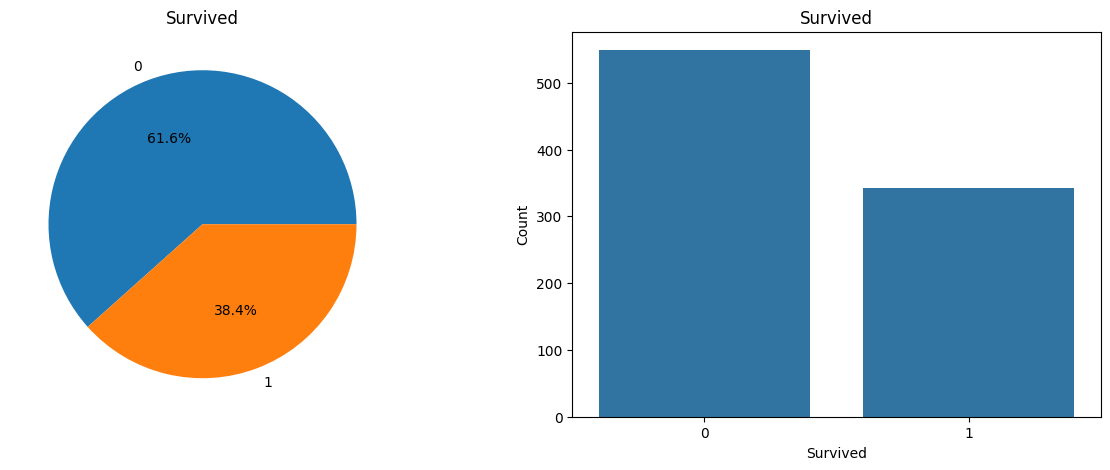

In [ ]:
# Survival Counts
f, ax = plt.subplots(1, 2, figsize = (15, 5))

ax[0].pie(survived, labels = ['0', '1'], autopct = '%1.1f%%')
ax[0].set_title('Survived')
ax[0].set_ylabel('')

sns.countplot(x = 'Survived', data = train_df, ax = ax[1])
ax[1].set_title('Survived')
ax[1].set_xlabel('Survived')
ax[1].set_ylabel('Count')


plt.show()

It can be seen that not many survived. Out of the 841 passengers, only **342 survived** or **38.4%** of the total passengers survived.

## Survival Analysis

### By Gender

In [ ]:
survived_sex = train_df.groupby('Sex')['Survived'].value_counts().reset_index()
survived_sex

,Sex,Survived,count
0,female,1,233
1,female,0,81
2,male,0,468
3,male,1,109


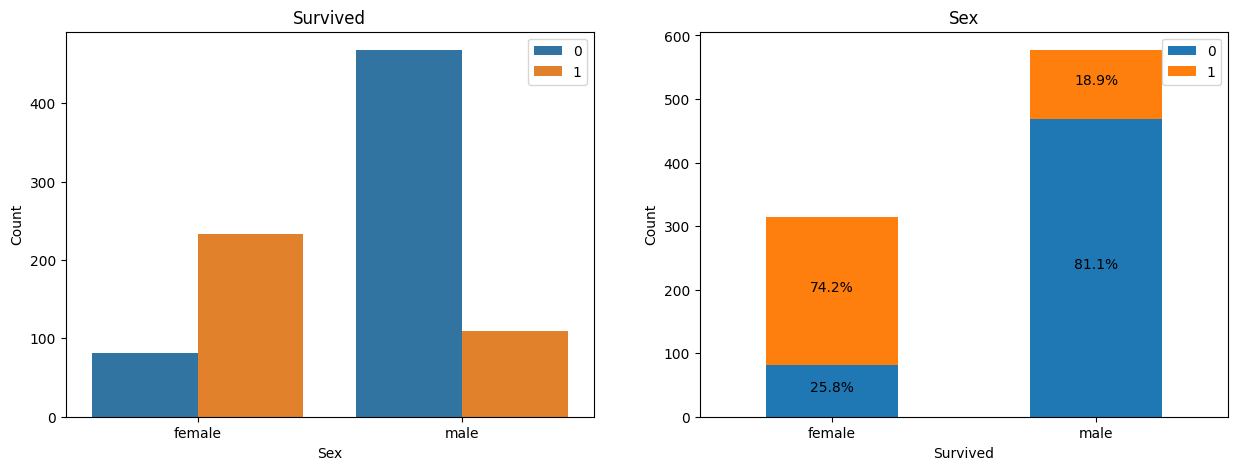

In [ ]:
# Survival Counts by Gender
f, ax = plt.subplots(1, 2, figsize = (15, 5))

sns.barplot(x = 'Sex', y = 'count', hue = 'Survived', data = survived_sex, ax = ax[0])
ax[0].set_title('Survived')
ax[0].set_xlabel('Sex')
ax[0].set_ylabel('Count')
ax[0].legend()


survived_sex_bar = train_df.groupby(['Sex', 'Survived']).size().unstack()
survived_sex_bar.plot(kind = 'bar', stacked = True, ax = ax[1])
total = survived_sex_bar.sum(axis = 1)
for i in range(len(survived_sex_bar)):
    # bawah
    pct1 = survived_sex_bar.iloc[i,0] / total.iloc[i] * 100
    ax[1].text(
        i,
        survived_sex_bar.iloc[i,0] / 2,
        f'{pct1:.1f}%',
        ha = 'center',
    )
    # atas
    pct2 = survived_sex_bar.iloc[i,1] / total.iloc[i] * 100
    ax[1].text(
        i,
        survived_sex_bar.iloc[i,0] + survived_sex_bar.iloc[i,1] / 2,
        f'{pct2:.1f}%',
        ha = 'center',
    )
ax[1].set_title('Sex')
ax[1].set_xlabel('Survived')
ax[1].tick_params(axis = 'x', labelrotation = 0)
ax[1].set_ylabel('Count')
ax[1].tick_params(axis = 'both')
ax[1].legend()

plt.show()

It can be seen that the number of male passengers is higher than the number of female passengers. However, the number of **male** passenger have a **lower survival rate** with **18.9%** while for **female** passenger is **74.2%**.

### By Pclass

In [ ]:
pclass = train_df['Pclass'].value_counts().reset_index()
pclass

,Pclass,count
0,3,491
1,1,216
2,2,184


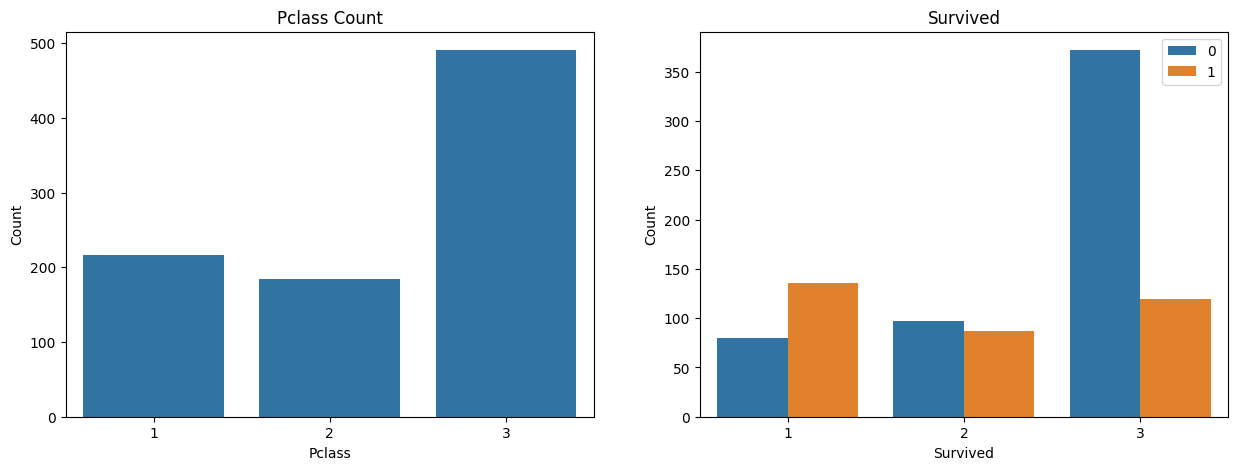

In [ ]:
# Survival by Pclass
f, ax = plt.subplots(1, 2, figsize = (15, 5))

sns.barplot(x = 'Pclass', y = 'count', data = pclass, ax = ax[0])
ax[0].set_title('Pclass Count')
ax[0].set_xlabel('Pclass')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis = 'both')

sns.countplot(x='Pclass', hue = 'Survived', data = train_df, ax = ax[1])
ax[1].set_title('Survived')
ax[1].set_xlabel('Survived')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis = 'both')
ax[1].legend()

plt.show()

It can be seen that most passengers are in Pclass 3. But the surival rate is lower than Pclass 1.



### By Age

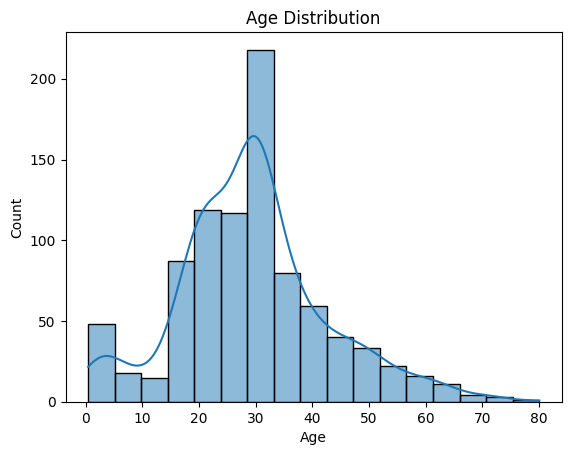

In [ ]:
sns.histplot(train_df['Age'],bins = 17,kde = True)

plt.title('Age Distribution')
plt.show()

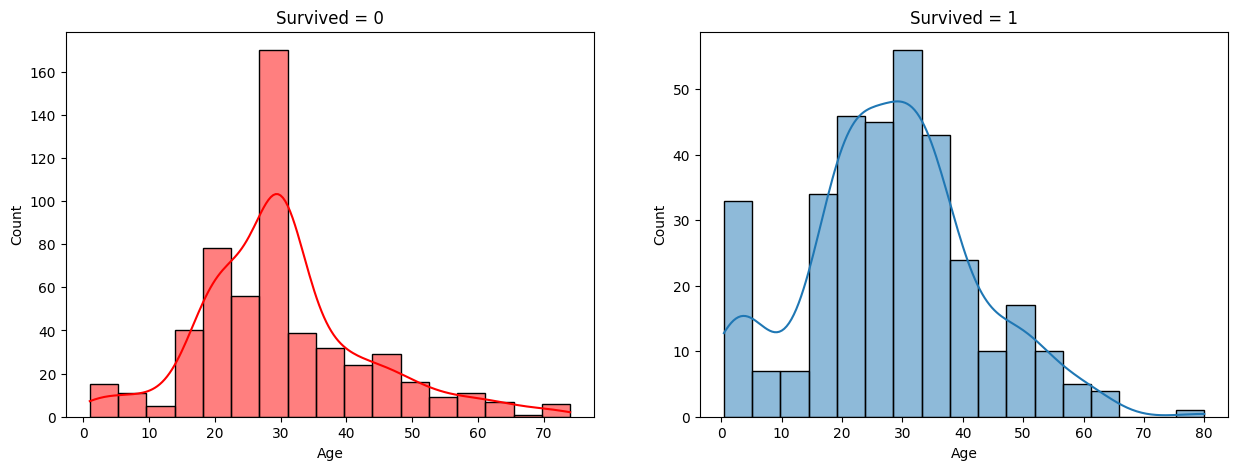

In [ ]:
# Survival by Age
f, ax = plt.subplots(1, 2, figsize = (15, 5))

sns.histplot(data = train_df[train_df['Survived'] == 0], x = 'Age',bins = 17,kde = True, color = 'red', ax = ax[0])
ax[0].set_title('Survived = 0')

sns.histplot(data = train_df[train_df['Survived'] == 1], x = 'Age',bins = 17,kde = True, ax = ax[1])
ax[1].set_title('Survived = 1')

plt.show()

The age distribution of **most passengers** is between **20-35 years**, with the highest frequency around age 30. The distribution appears positively skewed, indicating that most passengers are young adults. However, **children** had a relatively **higher survival rate**, suggesting that **younger** passengers may have had a **higher survival chance**.

### By Embarked

In [ ]:
embarked = train_df['Embarked'].value_counts().reset_index()
embarked

,Embarked,count
0,S,646
1,C,168
2,Q,77


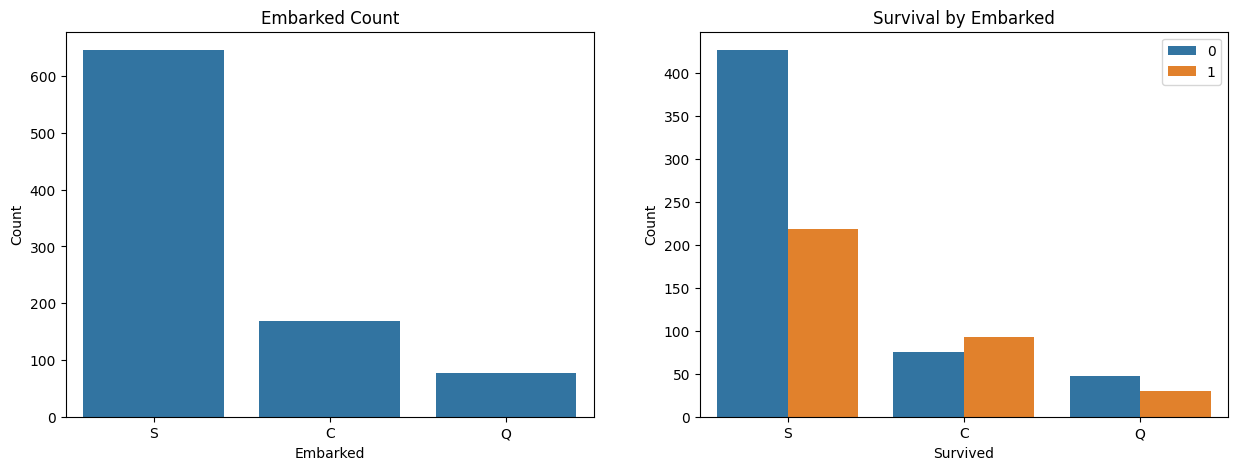

In [ ]:
 # Survival by Embarked
f, ax = plt.subplots(1, 2, figsize = (15, 5))

sns.barplot(x = 'Embarked', y = 'count', data = embarked, ax = ax[0])
ax[0].set_title('Embarked Count')
ax[0].set_xlabel('Embarked')
ax[0].set_ylabel('Count')

sns.countplot(x = 'Embarked', hue = 'Survived', data = train_df, ax = ax[1])
ax[1].set_title('Survived')
ax[1].set_xlabel('Survived')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis = 'both')
ax[1].legend()

plt.title('Survival by Embarked')
plt.show()

Most of the passengers boarder from Embarked Southampton. But, the survival rate is low.



### By Family Size

In [ ]:
# Family Size
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch']

family_size = train_df['Family_Size'].value_counts().reset_index()
family_size

,Family_Size,count
0,0,537
1,1,161
2,2,102
3,3,29
4,5,22
5,4,15
6,6,12
7,10,7
8,7,6


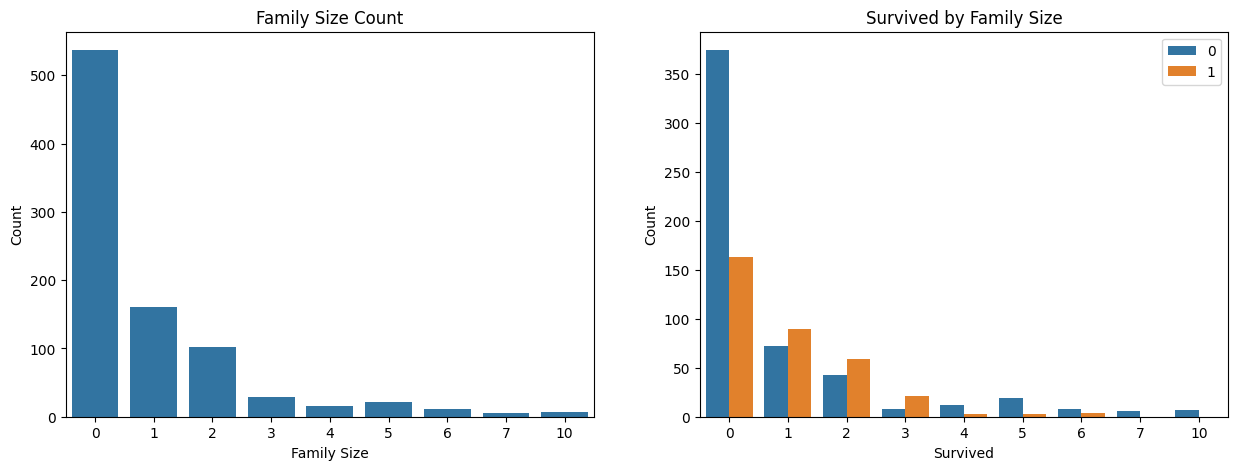

In [ ]:
# Family Size
f, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x = 'Family_Size', y = 'count', data = family_size, ax = ax[0])
ax[0].set_title('Family Size Count')
ax[0].set_xlabel('Family Size')
ax[0].set_ylabel('Count')


sns.countplot(x = 'Family_Size', hue = 'Survived', data = train_df, ax = ax[1])
ax[1].set_title('Survived by Family Size')
ax[1].set_xlabel('Survived')
ax[1].set_ylabel('Count')
ax[1].legend()

plt.show()

Most passengers traveled alone. Survival rate suggest that passengers with small families (1-3 members) tended to have better survival rate, while those traveling alone or with very large families showed lower survival rate. This indicates that family size may influence survival outcomes.

## Correlation

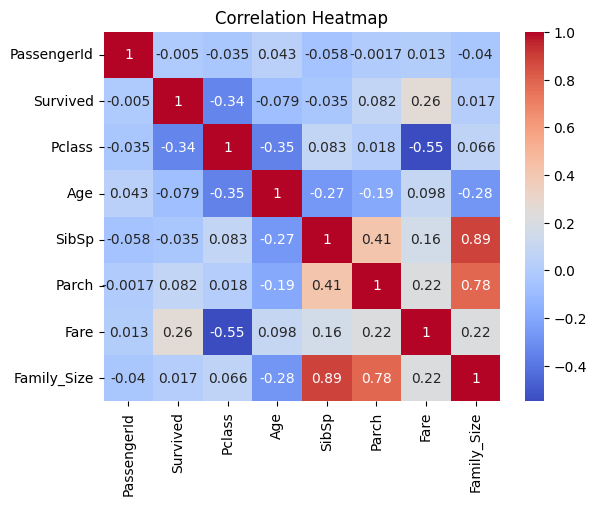

In [ ]:
# Correlation
sns.heatmap(train_df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Features Relationship

<Axes: xlabel='Pclass', ylabel='Survived'>

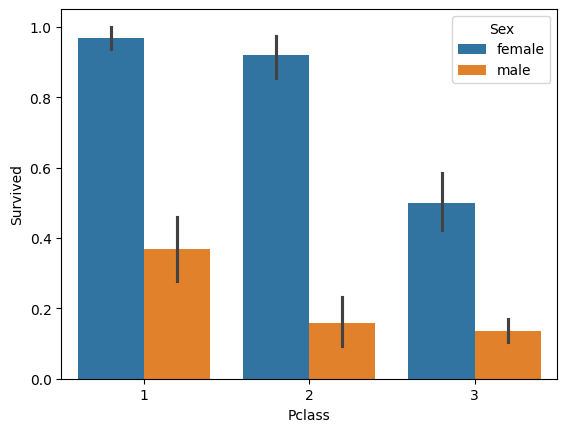

In [ ]:
sns.barplot(x = 'Pclass', y = 'Survived', hue = 'Sex', data = train_df)

<Axes: xlabel='Embarked', ylabel='Survived'>

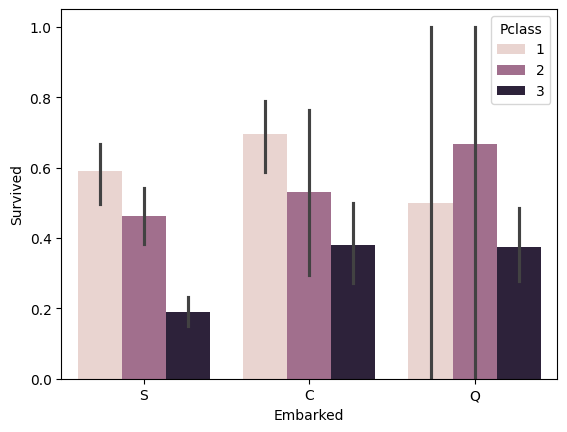

In [ ]:
sns.barplot(x = 'Embarked', y = 'Survived', hue = 'Pclass', data = train_df)

# PREDICTIVE MODELLING

## Train Test Split

In [ ]:
ml_train_df['Family_Size'] = ml_train_df['SibSp'] + ml_train_df['Parch'] + 1
test_df['Family_Size'] = test_df['SibSp'] + test_df['Parch'] + 1

In [ ]:
ml_train_df = ml_train_df.drop(['PassengerId', 'Name', 'Ticket','SibSp','Parch'], axis = 1)
test_passenger_id = test_df['PassengerId']
ml_test_df = test_df.drop(['PassengerId', 'Name', 'Ticket','SibSp','Parch'], axis = 1)

ml_train_df.head()


,Survived,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other,Family_Size
0,0,3,0,22.0,7.2500,0,0,1,0,0,1,0,0,2
1,1,1,1,38.0,71.2833,1,0,0,0,0,0,1,0,2
2,1,3,1,26.0,7.9250,0,0,1,0,1,0,0,0,1
3,1,1,1,35.0,53.1000,0,0,1,0,0,0,1,0,2
4,0,3,0,35.0,8.0500,0,0,1,0,0,1,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split

X = ml_train_df.drop('Survived', axis = 1)
y = ml_train_df['Survived']

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state = 10, stratify = y)

In [ ]:
from sklearn.preprocessing import StandardScaler

train_X_scaled = train_X.copy()
val_X_scaled = val_X.copy()

num_cols = ['Age', 'Fare', 'Family_Size']

scaler = StandardScaler()

train_X_scaled[num_cols] = scaler.fit_transform(train_X_scaled[num_cols])
val_X_scaled[num_cols] = scaler.transform(val_X_scaled[num_cols])

In [ ]:
from sklearn.metrics import accuracy_score

## Logistic Regression

In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

titanic_model_lr = LogisticRegression(max_iter = 3000)
titanic_model_lr.fit(train_X_scaled,train_y)

y_pred_lr = titanic_model_lr.predict(val_X_scaled)

lr_acc = accuracy_score(val_y, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_acc}")

Logistic Regression Accuracy: 0.8430493273542601


## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
titanic_model_dt = DecisionTreeClassifier()
titanic_model_dt.fit(train_X, train_y)

y_pred_dt = titanic_model_dt.predict(val_X)

dt_acc = accuracy_score(val_y, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_acc}")


Decision Tree Accuracy: 0.8385650224215246


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
titanic_model_rf = RandomForestClassifier(n_estimators = 100)
titanic_model_rf.fit(train_X, train_y)

y_pred_rf = titanic_model_rf.predict(val_X)

rf_acc = accuracy_score(val_y, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc}")

Random Forest Accuracy: 0.8251121076233184


## Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC
titanic_model_svm = SVC()
titanic_model_svm.fit(train_X_scaled, train_y)

y_pred_svm = titanic_model_svm.predict(val_X_scaled)

svm_acc = accuracy_score(val_y, y_pred_svm)
print(f"Support Vector Machine Accuracy: {svm_acc}")

Support Vector Machine Accuracy: 0.8609865470852018


## XGBoost

In [ ]:
from xgboost import XGBClassifier
titanic_model_xgb = XGBClassifier()
titanic_model_xgb.fit(train_X, train_y)

y_pred_xgb = titanic_model_xgb.predict(val_X)

xgb_acc = accuracy_score(val_y, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_acc}")

XGBoost Accuracy: 0.8609865470852018


# EVALUATION

In [ ]:
results = {}
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [ ]:
results['Logistic Regression Model'] = {'Accuracy' : accuracy_score(val_y, y_pred_lr),
                            'Precision' : precision_score(val_y, y_pred_lr),
                            'Recall' : recall_score(val_y, y_pred_lr),
                            'F1-Score' : f1_score(val_y, y_pred_lr),
                            'AUC-ROC' : roc_auc_score(val_y, y_pred_lr),
                            'Confusion Matrix' : confusion_matrix(val_y, y_pred_lr),
}

print('Classification Report:\n', classification_report(val_y, y_pred_lr))
print('Accuracy Score:', accuracy_score(val_y, y_pred_lr))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87       137
           1       0.80      0.79      0.80        86

    accuracy                           0.84       223
   macro avg       0.83      0.83      0.83       223
weighted avg       0.84      0.84      0.84       223

Accuracy Score: 0.8430493273542601


In [ ]:
results['Decision Tree'] = {'Accuracy' : accuracy_score(val_y, y_pred_dt),
                            'Precision' : precision_score(val_y, y_pred_dt),
                            'Recall' : recall_score(val_y, y_pred_dt),
                            'F1-Score' : f1_score(val_y, y_pred_dt),
                            'AUC-ROC' : roc_auc_score(val_y, y_pred_dt),
                            'Confusion Matrix' : confusion_matrix(val_y, y_pred_dt),
}

print('Classification Report:\n', classification_report(val_y, y_pred_dt))
print('Accuracy Score:', accuracy_score(val_y, y_pred_dt))

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       137
           1       0.80      0.77      0.79        86

    accuracy                           0.84       223
   macro avg       0.83      0.83      0.83       223
weighted avg       0.84      0.84      0.84       223

Accuracy Score: 0.8385650224215246


In [ ]:
results['Random Forest'] = {'Accuracy' : accuracy_score(val_y, y_pred_rf),
                            'Precision' : precision_score(val_y, y_pred_rf),
                            'Recall' : recall_score(val_y, y_pred_rf),
                            'F1-Score' : f1_score(val_y, y_pred_rf),
                            'AUC-ROC' : roc_auc_score(val_y, y_pred_rf),
                            'Confusion Matrix' : confusion_matrix(val_y, y_pred_rf),
}

print('Classification Report:\n', classification_report(val_y, y_pred_rf))
print('Accuracy Score:', accuracy_score(val_y, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       137
           1       0.78      0.77      0.77        86

    accuracy                           0.83       223
   macro avg       0.82      0.81      0.82       223
weighted avg       0.82      0.83      0.82       223

Accuracy Score: 0.8251121076233184


In [ ]:
results['SVM'] = {'Accuracy' : accuracy_score(val_y, y_pred_svm),
                            'Precision' : precision_score(val_y, y_pred_svm),
                            'Recall' : recall_score(val_y, y_pred_svm),
                            'F1-Score' : f1_score(val_y, y_pred_svm),
                            'AUC-ROC' : roc_auc_score(val_y, y_pred_svm),
                            'Confusion Matrix' : confusion_matrix(val_y, y_pred_svm),
}

print('Classification Report:\n', classification_report(val_y, y_pred_svm))
print('Accuracy Score:', accuracy_score(val_y, y_pred_svm))

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89       137
           1       0.86      0.77      0.81        86

    accuracy                           0.86       223
   macro avg       0.86      0.84      0.85       223
weighted avg       0.86      0.86      0.86       223

Accuracy Score: 0.8609865470852018


In [ ]:
results['XGBoost'] = {'Accuracy' : accuracy_score(val_y, y_pred_xgb),
                            'Precision' : precision_score(val_y, y_pred_xgb),
                            'Recall' : recall_score(val_y, y_pred_xgb),
                            'F1-Score' : f1_score(val_y, y_pred_xgb),
                            'AUC-ROC' : roc_auc_score(val_y, y_pred_xgb),
                            'Confusion Matrix': confusion_matrix(val_y, y_pred_xgb),
}

print('Classification Report:\n', classification_report(val_y, y_pred_xgb))
print('Accuracy Score:', accuracy_score(val_y, y_pred_xgb))

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89       137
           1       0.82      0.83      0.82        86

    accuracy                           0.86       223
   macro avg       0.85      0.85      0.85       223
weighted avg       0.86      0.86      0.86       223

Accuracy Score: 0.8609865470852018


In [ ]:
df_results = pd.DataFrame(results)
df_results.T

,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Confusion Matrix
Logistic Regression Model,0.843049,0.8,0.790698,0.795322,0.833305,"[[120, 17], [18, 68]]"
Decision Tree,0.838565,0.804878,0.767442,0.785714,0.825327,"[[121, 16], [20, 66]]"
Random Forest,0.825112,0.776471,0.767442,0.77193,0.814378,"[[118, 19], [20, 66]]"
SVM,0.860987,0.857143,0.767442,0.809816,0.843575,"[[126, 11], [20, 66]]"
XGBoost,0.860987,0.816092,0.825581,0.820809,0.854397,"[[121, 16], [15, 71]]"


In [ ]:
model = XGBClassifier()
model.fit(X,y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
test_pred = model.predict(ml_test_df)

In [ ]:
submission = pd.DataFrame({
    'PassengerId': test_passenger_id,
    'Survived': test_pred
})

submission.to_csv('submission.csv', index=False)